Cargando y limpiando datos...

Generando Huella Clínica (Heatmap)...


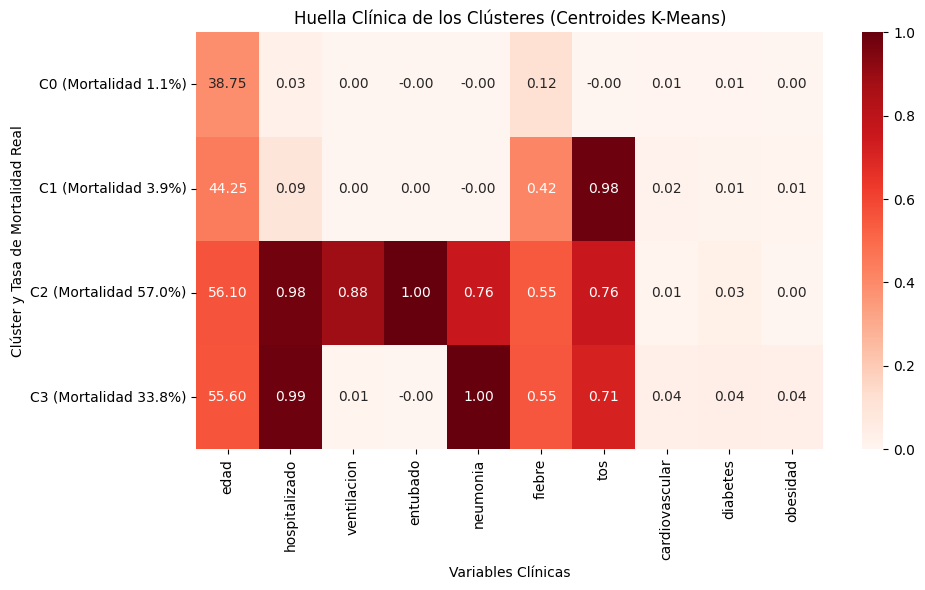


Generando Dendrograma Jerárquico...


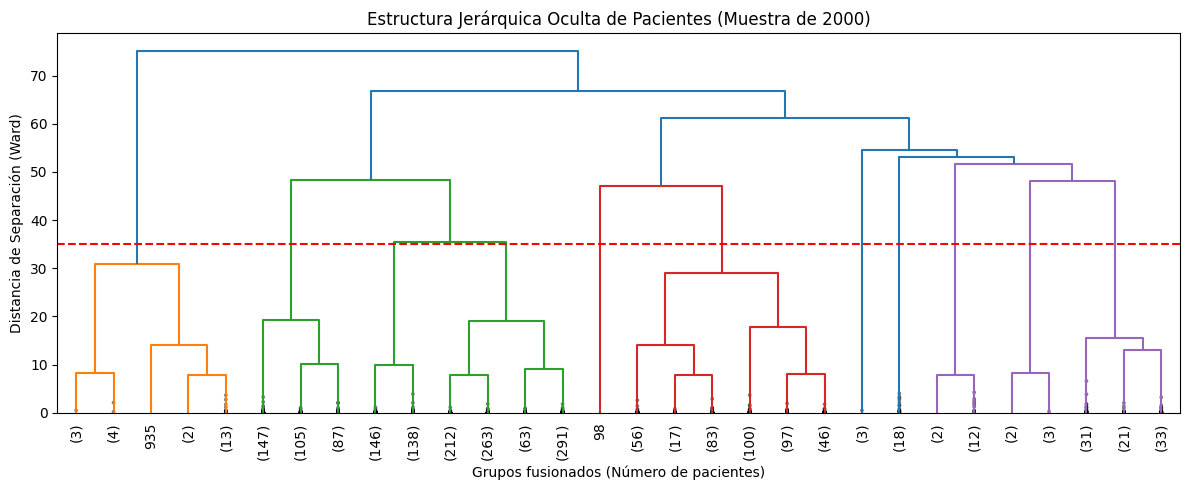


=== EXTRACCIÓN DE REGLAS DE ASOCIACIÓN (CO-OCURRENCIA) ===

Total casos analizados para reglas: 2315

1. Factores individuales más presentes en muertes:
   - MAYOR_50_AÑOS: presente en el 82.3% de las muertes
   - HOSPITALIZADO: presente en el 77.0% de las muertes
   - TOS: presente en el 61.5% de las muertes
   - FIEBRE: presente en el 40.8% de las muertes
   - NEUMONIA: presente en el 16.5% de las muertes

2. Reglas de Combinación Letal (Síntomas/Condiciones que ocurren juntas):
   - HOSPITALIZADO + MAYOR_50_AÑOS: 63.5%
   - MAYOR_50_AÑOS + TOS: 51.6%
   - HOSPITALIZADO + TOS: 50.2%
   - FIEBRE + MAYOR_50_AÑOS: 33.1%
   - FIEBRE + HOSPITALIZADO: 32.3%


In [2]:
"""
Análisis Avanzado de Mortalidad - Aprendizaje No Supervisado
(K-Means Profiling, Clustering Jerárquico y Reglas de Asociación)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from itertools import combinations
from collections import defaultdict

# ==========================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ==========================================
print("Cargando y limpiando datos...")
df = pd.read_csv("Base_coronavirus_31-05-2021.csv", encoding='latin1', sep=';', low_memory=False)

features_clinicas = ['edad', 'hospitalizado', 'ventilacion', 'entubado', 'neumonia',
                     'fiebre', 'tos', 'cardiovascular', 'diabetes', 'obesidad']

df_model = df[features_clinicas + ['evolucion']].copy()

# Aislamos el objetivo real (se oculta al modelo, solo se usa para validación)
df_model['fallecido'] = (df_model['evolucion'] == 'FALLECIÓ').astype(int)

# Binarización y limpieza
def encode_binary(val):
    if pd.isna(val): return 0
    if str(val).strip().upper() in ['SI', 'SÍ', '1', '1.0']: return 1
    return 0

for col in [c for c in features_clinicas if c != 'edad']:
    df_model[col] = df_model[col].apply(encode_binary)

df_model['edad'] = pd.to_numeric(df_model['edad'], errors='coerce')
df_model.loc[(df_model['edad'] < 0) | (df_model['edad'] > 110), 'edad'] = np.nan
df_model['edad'] = df_model['edad'].fillna(df_model['edad'].mean())

X = df_model[features_clinicas]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 2. HUELLA CLÍNICA (MAPA DE CALOR DE CENTROIDES)
# ==========================================
print("\nGenerando Huella Clínica (Heatmap)...")
km = KMeans(n_clusters=4, n_init=10, random_state=42)
df_model['cluster'] = km.fit_predict(X_scaled)

tasas = df_model.groupby('cluster')['fallecido'].mean().to_dict()
cluster_names = [f"C{c} (Mortalidad {tasas[c]*100:.1f}%)" for c in range(4)]

# Recuperamos los valores reales de los centroides (deshaciendo el escalado)
centroids = pd.DataFrame(scaler.inverse_transform(km.cluster_centers_), columns=features_clinicas)
centroids.index = cluster_names

plt.figure(figsize=(10, 6))
# Normalizamos temporalmente la edad para que el color en el mapa de calor tenga sentido visual junto a los 0s y 1s
centroids_viz = centroids.copy()
centroids_viz['edad'] = centroids_viz['edad'] / 100
sns.heatmap(centroids_viz, annot=centroids, cmap='Reds', fmt='.2f')
plt.title('Huella Clínica de los Clústeres (Centroides K-Means)')
plt.ylabel('Clúster y Tasa de Mortalidad Real')
plt.xlabel('Variables Clínicas')
plt.tight_layout()
plt.show()

# ==========================================
# 3. CLUSTERING JERÁRQUICO (DENDROGRAMA)
# ==========================================
print("\nGenerando Dendrograma Jerárquico...")
# Usamos una muestra porque el enlace (linkage) tiene una complejidad O(n^2) y puede colapsar la RAM
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), 2000, replace=False)
X_samp = X_scaled[sample_idx]

Z = linkage(X_samp, method='ward') # Método de Ward minimiza la varianza interna

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title('Estructura Jerárquica Oculta de Pacientes (Muestra de 2000)')
plt.xlabel('Grupos fusionados (Número de pacientes)')
plt.ylabel('Distancia de Separación (Ward)')
plt.axhline(y=35, color='r', linestyle='--') # Línea de corte sugerida
plt.tight_layout()
plt.show()

# ==========================================
# 4. REGLAS DE ASOCIACIÓN EN CASOS FATALES
# ==========================================
print("\n=== EXTRACCIÓN DE REGLAS DE ASOCIACIÓN (CO-OCURRENCIA) ===")
# Extraemos solo a los pacientes fallecidos para encontrar patrones recurrentes
fallecidos = df_model[df_model['fallecido'] == 1][features_clinicas]

def binarize_transaction(row):
    items = []
    if row['edad'] > 50: items.append('MAYOR_50_AÑOS') # Regla de negocio
    for col in features_clinicas:
        if col != 'edad' and row[col] == 1:
            items.append(col.upper())
    return items

transactions = fallecidos.apply(binarize_transaction, axis=1).tolist()
total_fallecidos = len(transactions)

item_counts = defaultdict(int)
pair_counts = defaultdict(int)

# Minería manual (análogo a algoritmos como Apriori o FP-Growth)
for transaction in transactions:
    for item in transaction:
        item_counts[item] += 1
    for pair in combinations(sorted(transaction), 2):
        pair_counts[pair] += 1

print(f"\nTotal casos analizados para reglas: {total_fallecidos}")
print("\n1. Factores individuales más presentes en muertes:")
for item, count in sorted(item_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   - {item}: presente en el {count/total_fallecidos*100:.1f}% de las muertes")

print("\n2. Reglas de Combinación Letal (Síntomas/Condiciones que ocurren juntas):")
for pair, count in sorted(pair_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"   - {pair[0]} + {pair[1]}: {count/total_fallecidos*100:.1f}%")